In [1]:
import datetime
import sys
# path为tools的上层文件夹
sys.path.append('D:\milimili')
import numpy as np
import pandas as pd
from configs import TE_app_token
from tools.数数查询 import get_sqldata
token=TE_app_token['Doomsday Vanguard']

In [42]:
sql="""
select * 
from 
(select 
"#user_id","#event_time" as time1
from ta.v_event_33  e 
where "$part_date" between '2024-01-16' and '2024-01-22'
and "#event_name" = 'firs_device_add'
and "#os" = 'Android'
and "#country_code" = 'JP') a 
left JOIN 
(
select "#user_id","#event_time" as ng_time,"currency_type","pay_amount"
from ta.v_event_33 
where "#event_name"= 'In_appPurchases_BuySuccess'
and "$part_date" between '2024-01-16' and '2024-01-23'
) b  on a."#user_id" = b."#user_id"
"""
df=get_sqldata(token,sql)

In [44]:
df.columns=['安装','安装时间','内购','内购时间','支付币种','金额']

In [55]:
def func(x):
    if x['内购']==x['安装']:
        hour = (pd.to_datetime(x['内购时间']) - pd.to_datetime(x['安装时间'])).total_seconds() / 3600
    else:
        hour = 0
    return hour

In [56]:
df['时间差']=df.apply(lambda x:func(x),axis=1)

In [59]:
df['安装hour']=df['安装时间'].astype('string').str.slice(11,13)

In [64]:
df=df[df['时间差']<=24]

In [66]:
df.replace('null',0,inplace=True)

In [69]:
df['金额']=df['金额'].astype('float')/147.8306

In [71]:
df1=df.groupby(by='安装hour',as_index=False)[['安装','金额']].agg({
    '安装':'nunique',
    '金额':'sum'
})

In [73]:
df1['d0_arpu'] = df1['金额']/df1['安装']

In [75]:
df1

,安装hour,安装,金额,d0_arpu
0,00,272,570.896418,2.098884
1,01,212,473.832684,2.235060
2,02,147,603.420401,4.104901
3,03,127,542.485791,4.271542
4,04,86,474.948894,5.522662
5,05,68,91.997191,1.352900
6,06,89,153.892361,1.729128
7,07,117,160.250990,1.369667
8,08,109,366.568153,3.363011
9,09,172,590.682782,3.434202


In [2]:
# 12月付费流失用户

sql="""
select "#user_id","tmp_rolenum","current_power","max_chapter_id","current_level",
"tmp_diamond","#adjust_network_name","total_gameplay_times","total_diamondget_num",
"total_goldcoinsget_num","total_recruittimes","total_ad_num","total_pay_amount"
from ta.v_user_33  u
where EXISTS (
SELECT "#user_id" FROM user_result_cluster_33  u2 WHERE "cluster_name"='cohort_20240122_165522' and u."#user_id"=u2."#user_id"
)
"""
ng_user=get_sqldata(token,sql)

In [3]:
ng_user.columns=['user_id','当前角色个数','当前战斗力','可挑战关卡','等级','当前钻石','渠道','游戏次数','累计获取钻石','累计获取金币','累计角色抽卡','累计广告次数','累计付费金额']

In [21]:
# 流失用户付费金额分布
ng_user['付费等级']=pd.cut(ng_user['累计付费金额'].astype('float'),# 需要分组的列
       bins=[0,1,10,20,50],# 分组的组数或者自定义分组列表
       right=False,# 是否包含右边的值
       # labels=[],# 显示标签
       include_lowest=True # 是否包含最低值
                      )

In [23]:
ng_user.groupby(by='付费等级',as_index=False)['user_id'].nunique()

,付费等级,user_id
0,"[0, 1)",4456
1,"[1, 10)",1413
2,"[10, 20)",677
3,"[20, 50)",430


In [28]:
ng_user.groupby(by='累计角色抽卡',as_index=False)['user_id'].nunique().sort_values(by='user_id',ascending=False).head(20)

,累计角色抽卡,user_id
162,6.0,559
146,5.0,544
188,8.0,378
177,7.0,317
200,9.0,284
128,4.0,271
1,10.0,267
78,21.0,246
9,11.0,245
59,18.0,228


In [83]:
# 付费流失用户的钻石消耗行为
sql="""
SELECT "#user_id","reason",sum(cast("change_num" as int))
FROM v_event_33 e1
WHERE "$part_event"='resource_change' 
AND "$part_date" between '2023-12-01'  and  '2024-01-07'
and EXISTS (SELECT "#user_id" FROM user_result_cluster_33  u WHERE "cluster_name"='cohort_20240122_165522' and e1."#user_id"=u."#user_id")
AND  "change_type" ='消耗'
and "resource_name" = '钻石'
group by "#user_id","reason"
"""
ng_user_change=get_sqldata(token,sql)

In [84]:
ng_user_change.columns=['user_id','操作行为','钻石消耗量']

In [85]:
ng_user_change=ng_user_change[ng_user_change['钻石消耗量']==ng_user_change['钻石消耗量']]

In [86]:
ng_user_change['钻石消耗量']=ng_user_change['钻石消耗量'].astype('int')

In [87]:
change_gp=ng_user_change.groupby(by='操作行为',as_index=False)[['user_id','钻石消耗量']].agg({
    'user_id':'nunique',
    '钻石消耗量':'sum'
})

In [88]:
change_gp

,操作行为,user_id,钻石消耗量
0,0,5941,-150
1,BuyDailyChallenge,65,-8800
2,BuyEnergy_AD,1726,0
3,BuyEnergy_Diamond,468,-149200
4,BuySeasonPassExp,56,-18780
5,ChipTreasury_Draw,6,-24000
6,Chip_DailyShop,15,-3306
7,NameChangeCost,647,-19560
8,Pet_DailyShop,54,-16377
9,RelicTreasury_Draw,93,-284100


In [5]:
ng_user.head()

,user_id,当前角色个数,当前战斗力,可挑战关卡,等级,当前钻石,渠道,游戏次数,累计获取钻石,累计获取金币,累计角色抽卡,累计广告次数,累计付费金额
0,1180064767100854272,8,296,6,13,489,Google Ads ACI,9.0,3759.0,661185.0,8.0,19.0,0.990000009536743
1,1180108335202967552,7,502,7,9,2364,Organic,12.0,3404.0,393570.0,7.0,1.0,0.990000009536743
2,1180124940410564608,13,706,8,20,1891,Organic,20.0,5856.0,1677287.0,24.0,15.0,0.990000009536743
3,1180146468854444032,12,1433,13,22,766,Gmo smaad,96.0,10161.0,3831195.0,29.0,120.0,0.990000009536743
4,1180151649050570752,13,273,3,10,116,Organic,8.0,2666.0,371892.0,18.0,1.0,3.980000019073483


In [2]:
# 12月次日流失时的用户属性
sql="""
select "#user_id","tmp_rolenum","current_power","max_chapter_id","current_level",
"tmp_diamond","#adjust_network_name","total_gameplay_times","total_diamondget_num",
"total_goldcoinsget_num","total_recruittimes","total_ad_num"
from ta.v_user_33  u
where EXISTS (
SELECT "#user_id" FROM user_result_cluster_33  u2 WHERE "cluster_name"='cohort_20240110_181155' and u."#user_id"=u2."#user_id"
)
"""
user_df=get_sqldata(token,sql)

In [30]:
# 次日流失用户流失时间线
sql="""
select a.*,b.last_time from 
(select "#user_id","#event_time","is_first_login"
from ta.v_event_33  e 
where EXISTS (SELECT "#user_id" FROM user_result_cluster_33  u2 WHERE "cluster_name"='cohort_20240110_181155' and e."#user_id"=u2."#user_id")
and "$part_date" between '2023-12-01' and '2023-12-31'
and "#event_name" = 'login'
and "is_first_login" = 'True') a 
left join 
(select "#user_id",max("#event_time") as last_time
from ta.v_event_33  e 
where EXISTS (SELECT "#user_id" FROM user_result_cluster_33  u2 WHERE "cluster_name"='cohort_20240110_181155' and e."#user_id"=u2."#user_id")
and "$part_date" between '2023-12-01' and '2023-12-31'
group by "#user_id") b
on a."#user_id" = b."#user_id"
"""
df_cr=get_sqldata(token,sql)

In [32]:
df_cr.columns=['user_id','首次登录时间','首次登录标识','流失时间']

In [34]:
# 计算分钟差 
df_cr['首次登录时间']=pd.to_datetime(df_cr['首次登录时间'])
df_cr['流失时间']=pd.to_datetime(df_cr['流失时间'])

In [38]:
df_cr['时间差']=(df_cr['流失时间']- df_cr['首次登录时间']).dt.total_seconds() / 60

In [78]:
df_cr=df_cr.query('时间差==时间差')

In [80]:
# 流失时间线分类
df_cr['流失时间点']=pd.cut(df_cr['时间差'].astype('float'),# 需要分组的列
       bins=[0,1,5,10,20,50,100,500,1000],# 分组的组数或者自定义分组列表
       right=False,# 是否包含右边的值
       # labels=[],# 显示标签
       include_lowest=True # 是否包含最低值
                      )



C:\Users\admin\AppData\Local\Temp\ipykernel_512\2086964316.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cr['流失时间点']=pd.cut(df_cr['时间差'].astype('float'),# 需要分组的列


In [82]:
df_cr.groupby(by='流失时间点',as_index=False)['user_id'].nunique()

,流失时间点,user_id
0,"[0, 1)",5796
1,"[1, 5)",6935
2,"[5, 10)",7666
3,"[10, 20)",6710
4,"[20, 50)",16202
5,"[50, 100)",6482
6,"[100, 500)",8565
7,"[500, 1000)",2769


In [77]:
# 12月三日流失时的用户属性
sql="""
select "#user_id","tmp_rolenum","current_power","max_chapter_id","current_level",
"tmp_diamond","#adjust_network_name","total_gameplay_times","total_diamondget_num",
"total_goldcoinsget_num","total_recruittimes","total_ad_num"
from ta.v_user_33  u
where EXISTS (
SELECT "#user_id" FROM user_result_cluster_33  u2 WHERE "cluster_name"='cohort_20240110_181455' and u."#user_id"=u2."#user_id"
)
"""
user_df3=get_sqldata(token,sql)

In [3]:
user_df.columns=['user_id','当前角色个数','当前战斗力','可挑战关卡','等级','当前钻石','渠道','游戏次数','累计获取钻石','累计获取金币','累计角色抽卡','累计广告次数']

In [78]:
user_df3.columns=['user_id','当前角色个数','当前战斗力','可挑战关卡','等级','当前钻石','渠道','游戏次数','累计获取钻石','累计获取金币','累计角色抽卡','累计广告次数']

In [79]:
user_df3.to_csv('三日流失用户属性.csv',index=False)

In [4]:
user_df.head()

,user_id,当前角色个数,当前战斗力,可挑战关卡,等级,当前钻石,渠道,游戏次数,累计获取钻石,累计获取金币,累计角色抽卡,累计广告次数
0,1167574070179401728,1,10,1,1,null,Organic,2.0,null,null,null,null
1,1154519455531798528,8,228,2,2,1130,Organic,2.0,4080.0,770.0,11.0,null
2,1168266825062944768,2,20,2,2,50,Organic,1.0,null,640.0,1.0,null
3,1151570689581395968,2,67,null,7,4964,Organic,1.0,4534.0,72000.0,1.0,null
4,1172737445884604416,1,10,2,2,50,Organic,1.0,null,1080.0,null,null


In [87]:
user_df3=user_df3.replace('null',0)

In [7]:
user_df=user_df.replace('null',0)

In [91]:
user_df3.shape

(12430, 12)

In [15]:
from matplotlib import  pyplot as plt

In [ ]:
# 流失前等级分布

In [88]:
user_level_df = user_df3.groupby(by='等级',as_index=False)['user_id'].nunique()

In [89]:
user_level_df.sort_values(by=['user_id'],ascending=False,inplace=True)

In [90]:
user_level_df

,等级,user_id
27,9,1986
3,11,1745
2,10,1727
26,8,1281
4,12,1241
12,2,922
25,7,894
5,13,727
6,14,470
20,3,348


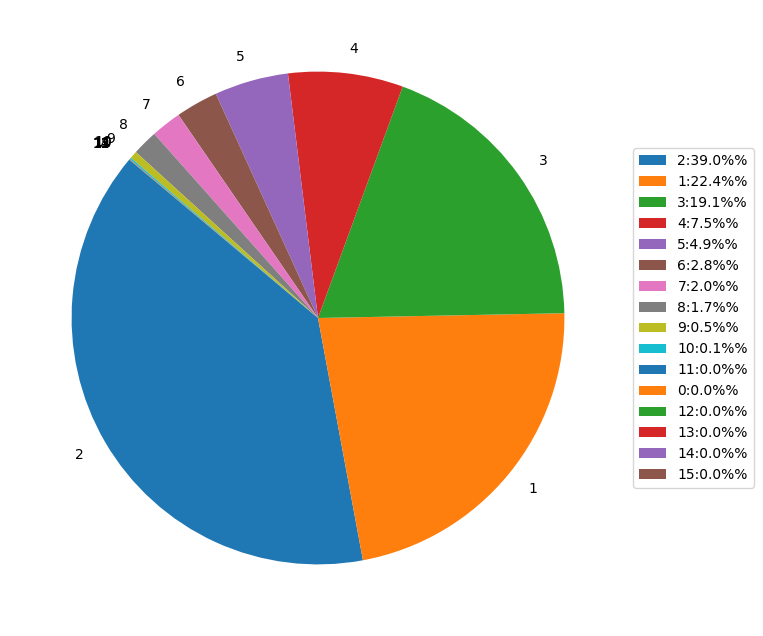

In [34]:
# 创建饼图
plt.figure(figsize=(8, 8))
patches, texts, autotexts=plt.pie(user_level_df['user_id'], labels=user_level_df['等级'], autopct='', startangle=140)

# 自定义图例
sizes=user_level_df['user_id']
percent = [f'{size/sum(sizes)*100:.1f}%' for size in user_level_df['user_id']]

legend_labels = [f'{label}:{size}%' for label,size  in zip(user_level_df['等级'], percent)]
plt.legend(patches, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

# 显示饼图
plt.show()

In [ ]:
# 流失前游戏次数分布

In [92]:
game_num=user_df3.groupby(by='游戏次数',as_index=False)['user_id'].nunique()

In [93]:
game_num.sort_values(by=['user_id'],ascending=False,inplace=True)

In [95]:
game_num.head(10)

,游戏次数,user_id
44,5.0,1333
34,4.0,1253
55,6.0,1181
23,3.0,1048
60,7.0,1016
63,8.0,837
65,9.0,690
2,10.0,594
12,2.0,567
4,12.0,412


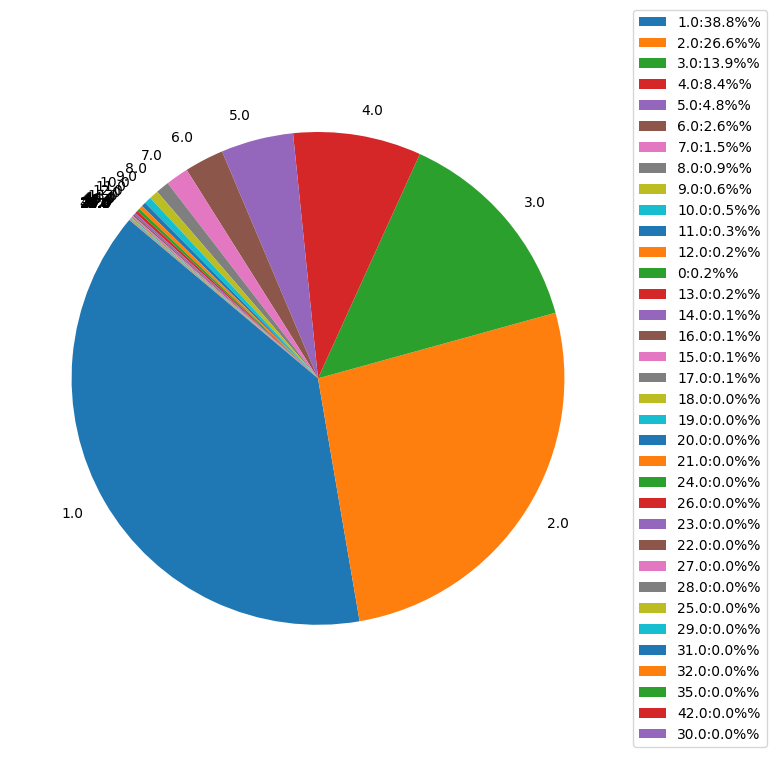

In [38]:
# 创建饼图
plt.figure(figsize=(8, 8))
patches, texts, autotexts=plt.pie(game_num['user_id'], labels=game_num['游戏次数'], autopct='', startangle=140)

# 自定义图例
sizes=game_num['user_id']
percent = [f'{size/sum(sizes)*100:.1f}%' for size in game_num['user_id']]

legend_labels = [f'{label}:{size}%' for label,size  in zip(game_num['游戏次数'], percent)]
plt.legend(patches, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

# 显示饼图
plt.show()

In [ ]:
# 流失前到达关卡分布

In [96]:
chat_id = user_df3.groupby(by='可挑战关卡',as_index=False)['user_id'].nunique()

In [97]:
chat_id.sort_values(by=['user_id'],ascending=False,inplace=True)

In [98]:
chat_id

,可挑战关卡,user_id
21,3,3398
26,5,1725
27,6,1675
25,4,1526
28,7,1008
29,8,1005
12,2,1001
30,9,584
1,1,173
3,11,109


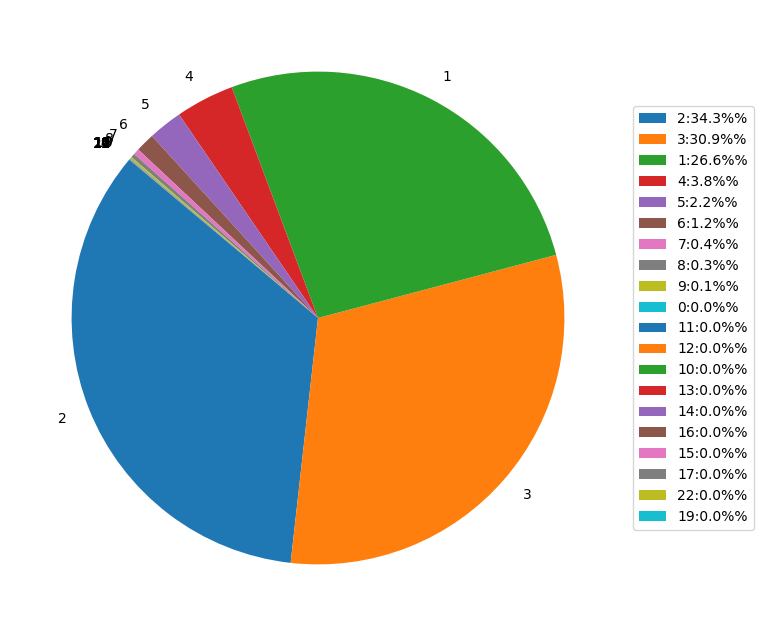

In [41]:
# 创建饼图
plt.figure(figsize=(8, 8))
patches, texts, autotexts=plt.pie(chat_id['user_id'], labels=chat_id['可挑战关卡'], autopct='', startangle=140)

# 自定义图例
sizes=chat_id['user_id']
percent = [f'{size/sum(sizes)*100:.1f}%' for size in chat_id['user_id']]

legend_labels = [f'{label}:{size}%' for label,size  in zip(chat_id['可挑战关卡'], percent)]
plt.legend(patches, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

# 显示饼图
plt.show()

In [ ]:
# 流失前广告次数

In [99]:
ad_num = user_df3.groupby(by='累计广告次数',as_index=False)['user_id'].nunique()

In [100]:
ad_num.sort_values(by=['user_id'],ascending=False,inplace=True)

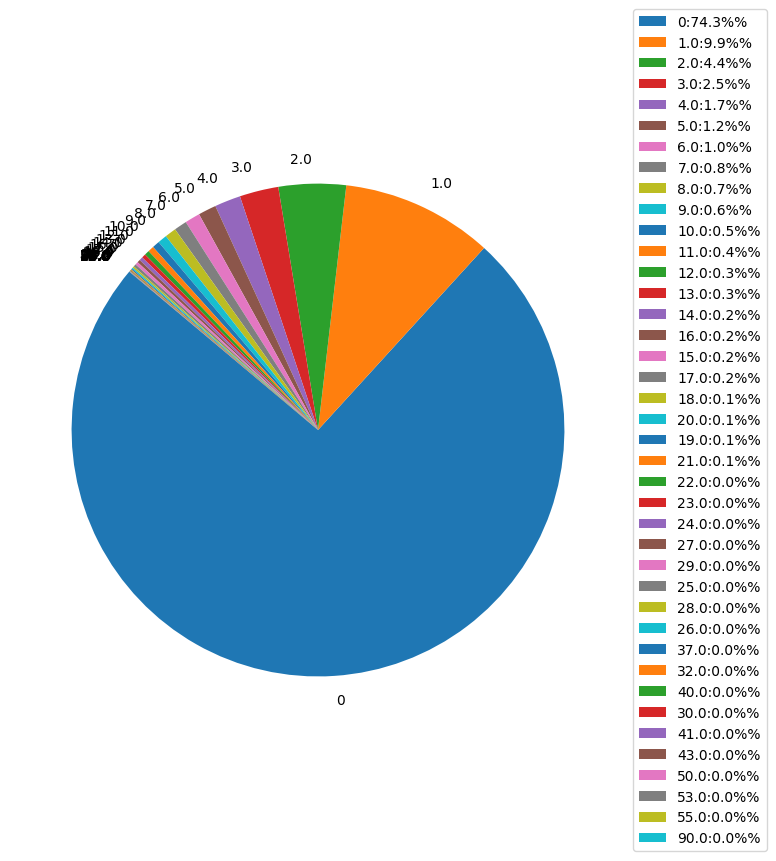

In [46]:
# 创建饼图
plt.figure(figsize=(8, 8))
patches, texts, autotexts=plt.pie(ad_num['user_id'], labels=ad_num['累计广告次数'], autopct='', startangle=140)

# 自定义图例
sizes=ad_num['user_id']
percent = [f'{size/sum(sizes)*100:.1f}%' for size in ad_num['user_id']]

legend_labels = [f'{label}:{size}%' for label,size  in zip(ad_num['累计广告次数'], percent)]
plt.legend(patches, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

# 显示饼图
plt.show()

In [ ]:
# 流失前抽卡

In [101]:
cart_num=user_df3.groupby(by='累计角色抽卡',as_index=False)['user_id'].nunique()

In [102]:
cart_num.sort_values(by=['user_id'],ascending=False,inplace=True)

In [119]:
cart_num.head(30)

,累计角色抽卡,user_id
30,2.0,1652
45,3.0,1434
1,1.0,1099
58,4.0,887
70,5.0,815
80,6.0,727
89,7.0,586
98,8.0,476
19,15.0,466
106,9.0,358


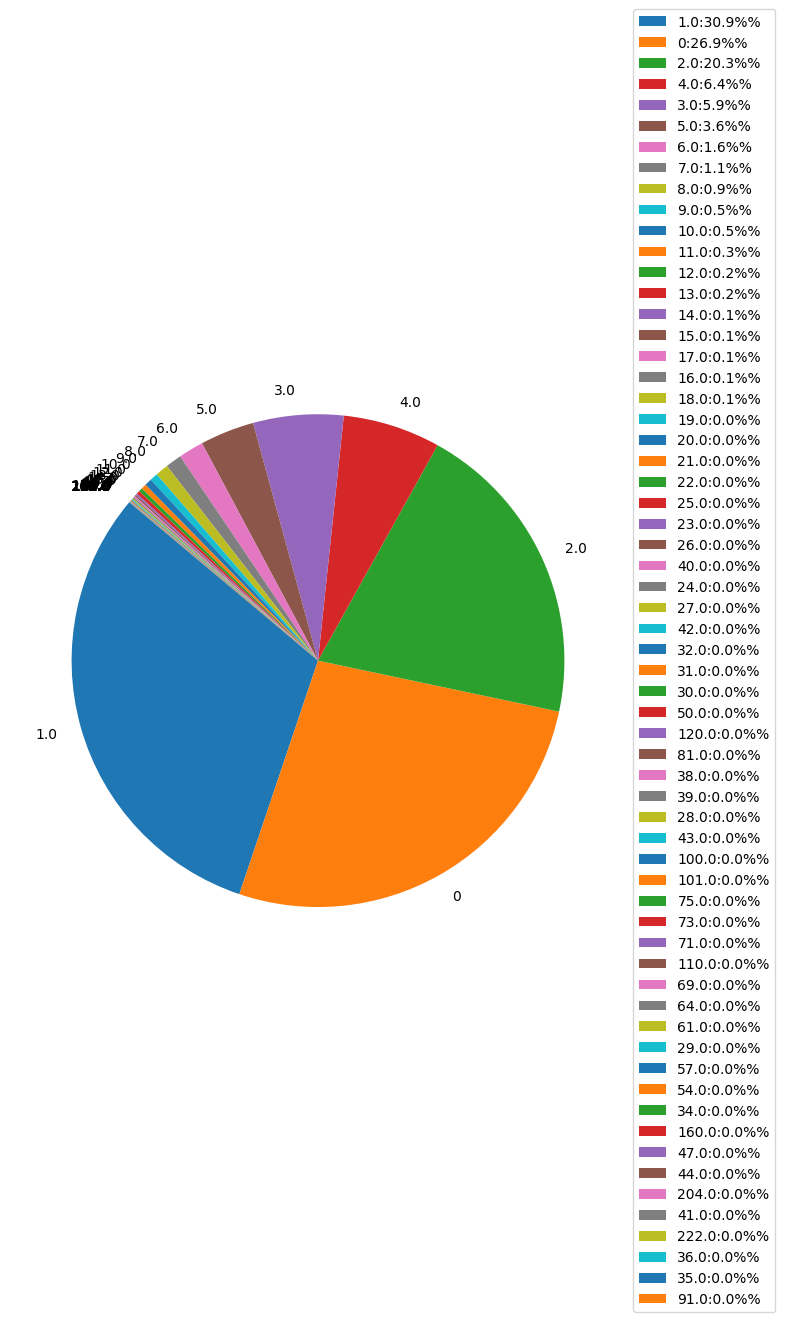

In [49]:
# 创建饼图
plt.figure(figsize=(8, 8))
patches, texts, autotexts=plt.pie(cart_num['user_id'], labels=cart_num['累计角色抽卡'], autopct='', startangle=140)

# 自定义图例
sizes=cart_num['user_id']
percent = [f'{size/sum(sizes)*100:.1f}%' for size in cart_num['user_id']]

legend_labels = [f'{label}:{size}%' for label,size  in zip(cart_num['累计角色抽卡'], percent)]
plt.legend(patches, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

# 显示饼图
plt.show()

In [9]:
# 流失前页面
sql="""
select * from (
select "#user_id","#event_name","page_name","#event_time",
rank() over(
PARTITION by "#user_id"
order by "#event_time" desc
) as rank1
from ta.v_event_33 e 
where EXISTS (
SELECT "#user_id" FROM user_result_cluster_33  u2 WHERE "cluster_name"='cohort_20240110_181155' and e."#user_id"=u2."#user_id"
)
and "$part_date" between '2023-12-01' and '2023-12-31'
and "#event_name"  ='page_enter'
) tab
where tab.rank1<=3
"""

page_df=get_sqldata(token,sql)


In [80]:
# 流失前页面
# cohort_20240110_181455
sql="""
select * from (
select "#user_id","#event_name","page_name","#event_time",
rank() over(
PARTITION by "#user_id"
order by "#event_time" desc
) as rank1
from ta.v_event_33 e 
where EXISTS (
SELECT "#user_id" FROM user_result_cluster_33  u2 WHERE "cluster_name"='cohort_20240110_181455' and e."#user_id"=u2."#user_id"
)
and "$part_date" between '2023-12-01' and '2023-12-31'
and "#event_name"  ='page_enter'
) tab
where tab.rank1<=3
"""

page_df3=get_sqldata(token,sql)

In [10]:
page_df.columns=['user_id','进入页面','详细页面','时间','顺序']

In [81]:
page_df3.columns=['user_id','进入页面','详细页面','时间','顺序']

In [82]:
page_df3.to_csv('三日流失用户页面.csv',index=False)

In [104]:
# 最后一次页面
last_page= page_df3[page_df3['顺序']=='1'] 

In [105]:
last_page_info=last_page.groupby(by='详细页面',as_index=False)['user_id'].nunique()
last_page_info['占比']=last_page_info['user_id']/last_page_info['user_id'].sum()

In [106]:
last_page_info.sort_values(by='占比',ascending=False,inplace=True)

In [120]:
last_page_info

,详细页面,user_id,占比
35,游戏内,1445,0.138211
21,战斗主页面,1346,0.128742
6,商店页面,1110,0.106169
51,角色界面,765,0.073171
2,人才市场界面,631,0.060354
37,登录页面,587,0.056145
20,战地补给,404,0.038642
49,装备页面,352,0.033668
7,图鉴,342,0.032712
15,巡逻页面,299,0.028599


In [ ]:
# 流失前三次页面

In [108]:
last_page3=page_df3.groupby(by='详细页面',as_index=False)['user_id'].nunique()
last_page3['占比']=last_page3['user_id']/last_page3['user_id'].sum()
last_page3.sort_values(by='占比',ascending=False,inplace=True)

In [122]:
last_page3.head(50)

,详细页面,user_id,占比
23,战斗主页面,3906,0.137895
38,游戏内,2643,0.093307
6,商店页面,2584,0.091224
24,技能选择页面,2277,0.080386
54,角色界面,1933,0.068241
52,装备页面,1754,0.061922
2,人才市场界面,1712,0.060439
51,装备详细页面,1070,0.037774
22,战地补给,863,0.030467
40,登录页面,794,0.028031


In [12]:
# 流失前最后几次事件
sql="""
select * from (
select "#user_id","#event_name","#event_time",
rank() over(
PARTITION by "#user_id"
order by "#event_time" desc
) as rank1
from ta.v_event_33 e 
where EXISTS (
SELECT "#user_id" FROM user_result_cluster_33  u2 WHERE "cluster_name"='cohort_20240110_181155' and e."#user_id"=u2."#user_id"
)
and "$part_date" between '2023-12-01' and '2023-12-31'
and "#event_name"  in  ('Game_Level_enter','In_appPurchases_BuySuccess','In_appPurchases_BuyFailed','equipment','draw_card','role_recruit') 
) tab
where tab.rank1  <=3
"""
event_df=get_sqldata(token,sql)


In [83]:
# 流失前最后几次事件
sql="""
select * from (
select "#user_id","#event_name","#event_time",
rank() over(
PARTITION by "#user_id"
order by "#event_time" desc
) as rank1
from ta.v_event_33 e 
where EXISTS (
SELECT "#user_id" FROM user_result_cluster_33  u2 WHERE "cluster_name"='cohort_20240110_181455' and e."#user_id"=u2."#user_id"
)
and "$part_date" between '2023-12-01' and '2023-12-31'
and "#event_name"  in  ('Game_Level_enter','In_appPurchases_BuySuccess','In_appPurchases_BuyFailed','equipment','draw_card','role_recruit') 
) tab
where tab.rank1  <=3
"""
event_df3=get_sqldata(token,sql)

In [13]:
event_df.columns=['user_id','事件','时间','顺序']

In [84]:
event_df3.columns=['user_id','事件','时间','顺序']

In [85]:
event_df3.to_csv('三日流失用户流失前事件.csv',index=False)

In [110]:
last_event = event_df3[event_df3['顺序']=='1']

In [111]:
last_event=last_event.groupby(by='事件',as_index=False)['user_id'].nunique()
last_event['占比']=last_event['user_id']/last_event['user_id'].sum()
last_event.sort_values(by='占比',ascending=False,inplace=True)

In [112]:
last_event

,事件,user_id,占比
0,Game_Level_enter,3997,0.382708
3,equipment,3854,0.369016
4,role_recruit,1908,0.182689
2,draw_card,544,0.052087
1,In_appPurchases_BuyFailed,141,0.013501


In [113]:
last_event3=event_df3.groupby(by='事件',as_index=False)['user_id'].nunique()
last_event3['占比']=last_event3['user_id']/last_event3['user_id'].sum()
last_event3.sort_values(by='占比',ascending=False,inplace=True)

In [114]:
last_event3.head(10)

,事件,user_id,占比
4,equipment,7969,0.409528
0,Game_Level_enter,5794,0.297754
5,role_recruit,4080,0.209672
3,draw_card,1288,0.066190
1,In_appPurchases_BuyFailed,320,0.016445
2,In_appPurchases_BuySuccess,8,0.000411
